In [5]:
#import sys
#!{sys.executable} -m pip install -qq matplotlib seaborn

In [6]:
import pandas as pd
import pandasql as psql
import re
import matplotlib.pyplot as plt

In [7]:
def load_data():
    sales = pd.read_csv("C:\myCODE\AgenticAIReporting\data\sales.csv")
    products = pd.read_csv("C:\myCODE\AgenticAIReporting\data\products.csv")
    stores = pd.read_csv("C:\myCODE\AgenticAIReporting\data\stores.csv")

    table_metadata = """Table: products; Columns: product_id	,product_name ,category	,brand	,price;
                        Table: sales; Columns: sale_id	,product_id	,store_id	,quantity	,sale_date;
                        Table: stores; Columns:store_id	,store_name	,city	,state	,region; """
    
    return sales, products, stores, table_metadata

sales, products, stores, table_metadata = load_data()

In [8]:
products.sample(3)

,product_id,product_name,category,brand,price
195,196,Product_196,Accessories,Dyson,1734.73
731,732,Product_732,Electronics,Dell,23.62
659,660,Product_660,Accessories,Adidas,168.93


In [9]:
sales.sample(3)

,sale_id,product_id,store_id,quantity,sale_date
47732,47733,706,196,4,2024-05-12
49218,49219,912,129,9,2024-06-14
45146,45147,485,148,12,2024-12-16


In [10]:
stores.sample(3)

,store_id,store_name,city,state,region
170,171,Store_171,San Francisco,CA,East
189,190,Store_190,New York,IL,East
29,30,Store_30,Chicago,CA,West


In [57]:
import os
import langchain
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(model="gpt-5-nano",api_key=os.getenv("OPENAI_API_KEY"))

from langchain_google_genai import ChatGoogleGenerativeAI
llm_gai = ChatGoogleGenerativeAI(model="gemini-2.5-flash",api_key=os.getenv("GEMINI_API_KEY"), temperature=0.0)

#prompt template
from langchain.prompts import PromptTemplate
template = """You are a SQL data analyst. You help write sql code and visualize the results in charts.

Write a SQL query to answer the following question with only the tables/columns provided in metadata: 
Only return the SQL query starting with the Keyword "SQLQuery": Do not explain.
Suggest a visualization to display above Result, starting with the Keyword "Chart:".Do not explain. choose one of (bar, pie, line,scatter, table)
Add comment in query field selection to indicate 2 coordinates for the chart. use ("-- x coordinate", "-- y coordinate") Do not rename the query result field names.
Sample:
SQLQuery:
SELECT d.department_name as Department             -- x coordinate (Department)
        , count(e.employee_id) as Employees        -- y coordinate (Employee Count)
FROM employee e
JOIN department d on e.department_id=d.department_id

Chart: bar chart


Metadata = {metadata} 
Question: {question}"""
prompt = PromptTemplate(template=template, input_variables=["metadata","question"])

from langchain.schema import StrOutputParser
chain = prompt | llm | StrOutputParser()
chain_gai = prompt | llm_gai | StrOutputParser()

def invoke_llm_openai(question:str,table_metadata:str):
    response = chain.invoke({"question": question,"metadata":table_metadata})
    return response

def invoke_llm_gai(question:str,table_metadata:str):
    response = chain_gai.invoke({"question": question,"metadata":table_metadata})
    return response

In [12]:
Question = "show volume of sales, revenue by product category"

llm_result = invoke_llm_gai(Question,table_metadata) 

print(llm_result)

SQLQuery:
SELECT p.category AS Category                 -- x coordinate (Category)
        , SUM(s.quantity) AS "Volume of Sales" -- y coordinate (Volume of Sales)
        , SUM(s.quantity * p.price) AS Revenue -- y coordinate (Revenue)
FROM sales s
JOIN products p ON s.product_id = p.product_id
GROUP BY p.category;

Chart: bar chart


In [13]:
def parse_sql_and_chart(parse_text):
    # Extract SQL query
    sql_query_match = re.search(r"sqlquery:\s*(select[\s\S]+?)\s*chart:", parse_text, re.IGNORECASE)
    sql_query = sql_query_match.group(1).strip() if sql_query_match else None

    # Extract chart suggestion
    chart_match = re.search(r"Chart:\s*(.*)", parse_text, re.IGNORECASE)
    chart_text = chart_match.group(1).strip() 
    print(chart_match)
    # Map common chart types
    if "bar" in chart_text:
        chart_type = "bar"
    elif "pie" in chart_text:
        chart_type = "pie"
    elif "line" in chart_text:
        chart_type = "line"
    else:
        chart_type = "table"

    # Extract x and y coordinates from SQL comments
    # Look for "-- X coordinate (...)" or "-- Y coordinate (...)" in SELECT lines
    x_coord, y_coord = None, None
    select_lines = parse_text.splitlines()
    for line in select_lines:
        if "-- x coordinate" in line:
            if " as " in line:
                x_coord = line.split("as")[1].split()[0].strip().strip(',')
            elif " AS " in line:
                x_coord = line.split("AS")[1].split()[0].strip().strip(',')    
            else:
                x_coord = line.split(".")[1].split()[0].strip().strip(',')  
        if "-- y coordinate" in line:
            if " as " in line:
                y_coord = line.split("as")[1].split()[0].strip().strip(',') 
            elif " AS " in line:
                y_coord = line.split("AS")[1].split()[0].strip().strip(',')     
            else:
                y_coord = line.split(".")[1].split()[0].strip().strip(',')  

    return {
        "sql_query": sql_query,
        "chart": chart_type,
        "x_coordinate": x_coord,
        "y_coordinate": y_coord
    }

st = """SQLQuery:
SELECT p.category AS Category                               -- x coordinate (Category)
        , SUM(s.quantity) AS "Volume of Sales"
        , SUM(s.quantity * p.price) AS Revenue              -- y coordinate (Revenue)
FROM sales s
JOIN products p ON s.product_id = p.product_id
GROUP BY p.category;

Chart: bar chart"""
parsed = parse_sql_and_chart(st)
print("SQLQuery:\n", parsed['sql_query'])
print(f"Chart: {parsed['chart']} ; X : {parsed['x_coordinate']}; Y : {parsed['y_coordinate']}")

<re.Match object; span=(312, 328), match='Chart: bar chart'>
SQLQuery:
 SELECT p.category AS Category                               -- x coordinate (Category)
        , SUM(s.quantity) AS "Volume of Sales"
        , SUM(s.quantity * p.price) AS Revenue              -- y coordinate (Revenue)
FROM sales s
JOIN products p ON s.product_id = p.product_id
GROUP BY p.category;
Chart: bar ; X : Category; Y : Revenue


In [14]:
def query_validate(query: str):
    forbidden = ["insert","update","delete","drop","alter","create","truncate","attach"]
    for kw in forbidden:
        if re.search(r"\b"+kw+r"\b" , query.lower()):
            return False, "forbidden keyword found: "+kw
    return True, "Passed"    

query_validate(parsed['sql_query'])   

(True, 'Passed')

In [15]:
def run_sql(query:str):
    try:
        result = psql.sqldf(query, globals())  # You can use locals() if inside a function
        print(f"[SQL] Query executed successfully. Rows returned: {len(result)}")
        return result
    except Exception as e:
        print(f"[ERROR] Failed to execute query:\n{query}\nReason: {e}")
        return None

run_sql(parsed['sql_query'])

[SQL] Query executed successfully. Rows returned: 8


,Category,Volume of Sales,Revenue
0,Accessories,117425,1.159041e+08
1,Books,119661,1.236788e+08
2,Clothing,113495,1.178641e+08
3,Electronics,129875,1.352909e+08
4,Furniture,112217,1.172394e+08
5,Home,147074,1.335571e+08
6,Sports,125144,1.263029e+08
7,Toys,134910,1.365074e+08


In [56]:
def display_bar(df, x: str, y: str):
    try:
        plt.figure(figsize=(6, 4))
        plt.bar(df[x], df[y], color='skyblue')
        plt.xlabel(x)
        plt.ylabel(y)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"[ERROR] display_bar failed: {e}")

def display_line(df, x: str, y: str):
    try:
        plt.figure(figsize=(6, 4))
        plt.plot(df[x], df[y], marker='o', linestyle='-', color='blue')
        plt.xlabel(x)
        plt.ylabel(y)
        plt.xticks(rotation=45)
        plt.grid(True)
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"[ERROR] display_line failed: {e}")

def display_pie(df, x: str, y: str):
    try:
        if len(df) > 20:
            print("[WARN] Too many categories for pie chart. Showing top 20.")
            df = df.nlargest(20, y)  # avoid overload

        plt.figure(figsize=(5,5))
        plt.pie(df[y], labels=df[x], autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"[ERROR] display_pie failed: {e}")

def display_scatter(df, x: str, y: str):
    try:
        plt.figure(figsize=(6, 4))
        plt.scatter(df[x], df[y], color='purple', alpha=0.7)
        plt.xlabel(x)
        plt.ylabel(y)
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"[ERROR] display_scatter failed: {e}")


def display_grid(df):
    try:
        print(df.head(20)) 
    except Exception as e:
        print(f"[ERROR] display_grid failed: {e}")

def display_chart(chart:str ,df,x :str, y: str):
    if df is None or df.empty:
        print("[WARN] No data to display.")
        return

    if chart == "bar":
        display_bar(df, x, y)
    elif chart == "line":
        display_line(df, x, y)
    elif chart == "pie":
        display_pie(df, x, y)
    elif chart == "scatter":
        display_scatter(df, x, y)
    elif chart == "table":
        display_grid(df)
    else:
        print(f"[WARN] Unknown chart type: {chart}")
    return

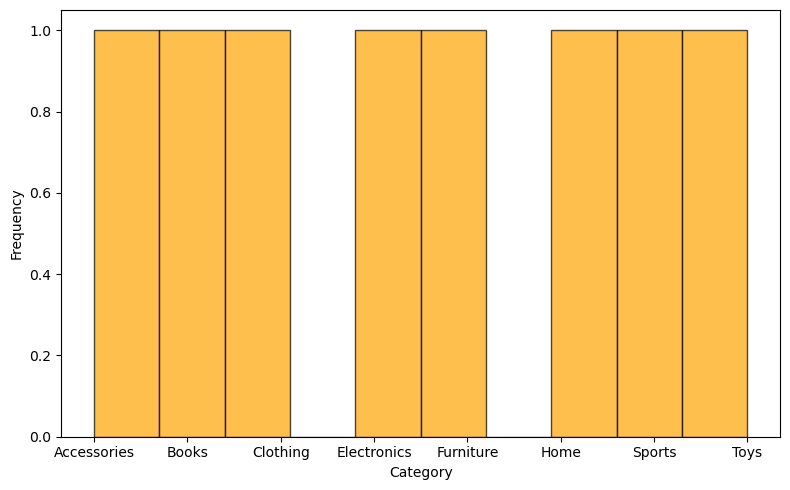

In [55]:
display_chart('area',result,parsed["x_coordinate"] , parsed["y_coordinate"])

In [19]:
def load_prompt(Question:str,table_metadata:str):

        prompt = f"""You are a SQL data analyst. You help write sql code and visualize the results in charts.

        Write a SQL query to answer the following question with only the tables/columns provided in metadata: 
        Only return the SQL query starting with the Keyword "SQLQuery": Do not explain.
        Suggest a visualization to display above Result, starting with the Keyword "Chart:".Do not explain. choose one of (bar, pie, line, table)
        Add comment in query field selection to indicate 2 coordinates for the chart. use ("-- x coordinate", "-- y coordinate") Do not rename the query result field names.
        Sample:
        SQLQuery:
        SELECT d.department_name as Department             -- x coordinate (Department)
                , count(e.employee_id) as Employees        -- y coordinate (Employee Count)
        FROM employee e
        JOIN department d on e.department_id=d.department_id

        Chart: bar chart


        Metadata = {table_metadata} 
        Question: {Question} """

        return (prompt)
Question = "show volume of sales, revenue by product category"
p =load_prompt(Question,table_metadata)   
print(p)    

You are a SQL data analyst. You help write sql code and visualize the results in charts.

        Write a SQL query to answer the following question with only the tables/columns provided in metadata: 
        Only return the SQL query starting with the Keyword "SQLQuery": Do not explain.
        Suggest a visualization to display above Result, starting with the Keyword "Chart:".Do not explain. choose one of (bar, pie, line, table)
        Add comment in query field selection to indicate 2 coordinates for the chart. use ("-- x coordinate", "-- y coordinate") Do not rename the query result field names.
        Sample:
        SQLQuery:
        SELECT d.department_name as Department             -- x coordinate (Department)
                , count(e.employee_id) as Employees        -- y coordinate (Employee Count)
        FROM employee e
        JOIN department d on e.department_id=d.department_id

        Chart: bar chart


        Metadata = Table: products; Columns: product_id	,product_

data load complete
Prompt: You are a SQL data analyst. You help write sql code and visualize the results in charts.

        Write a SQL query to answer the following question with only the tables/columns provided in metadata: 
        Only return the SQL query starting with the Keyword "SQLQuery": Do not explain.
        Suggest a visualization to display above Result, starting with the Keyword "Chart:".Do not explain. choose one of (bar, pie, line, table)
        Add comment in query field selection to indicate 2 coordinates for the chart. use ("-- x coordinate", "-- y coordinate") Do not rename the query result field names.
        Sample:
        SQLQuery:
        SELECT d.department_name as Department             -- x coordinate (Department)
                , count(e.employee_id) as Employees        -- y coordinate (Employee Count)
        FROM employee e
        JOIN department d on e.department_id=d.department_id

        Chart: bar chart


        Metadata = Table: products; Co

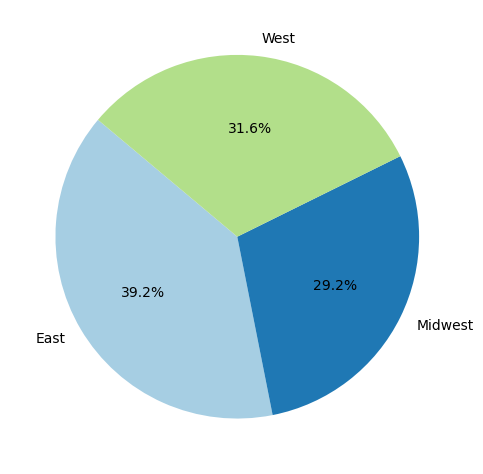

In [59]:
sales, products, stores, table_metadata =load_data()
print ("data load complete")
#    table_metadata = """Table: products; Columns: product_id	,product_name ,category	,brand	,price;
#                        Table: sales; Columns: sale_id	,product_id	,store_id	,quantity	,sale_date;
#                        Table: stores; Columns:store_id	,store_name	,city	,state	,region; """

Question = "show revenue by region in pie chart"
prompt = load_prompt(Question,table_metadata) 
print(f"Prompt:",prompt)

#llm_result = invoke_llm(prompt) 

llm_result = """SQLQuery:

SELECT st.region                          -- x coordinate (Region)
       , SUM(s.quantity * p.price) AS Revenue   -- y coordinate (Revenue)
FROM sales s
JOIN products p ON s.product_id = p.product_id
JOIN stores st ON s.store_id = st.store_id
GROUP BY st.region;


Chart: pie chart"""

print(f"AI suggestion: ")
print(llm_result)

parsed = parse_sql_and_chart(llm_result)
print(parsed)

valid, msg = query_validate(parsed["sql_query"])
print(f"Query Validation")
print(valid ,msg)
if valid:
    print(f"Execute Query")
    result = run_sql(parsed['sql_query'])   
    print (result) 
    display_chart(parsed["chart"],result,parsed["x_coordinate"] , parsed["y_coordinate"])
else:
    print("modify the query for the LLM to answer query")



data load complete
AI suggestion: 
SQLQuery:
SELECT p.category AS Category                               -- x coordinate (Category)
        , SUM(s.quantity) AS "Volume of Sales"
        , SUM(s.quantity * p.price) AS Revenue              -- y coordinate (Revenue)
FROM sales s
JOIN products p ON s.product_id = p.product_id
GROUP BY p.category;

Chart: bar chart
<re.Match object; span=(312, 328), match='Chart: bar chart'>
Query Validation
True Passed
[SQL] Query executed successfully. Rows returned: 8


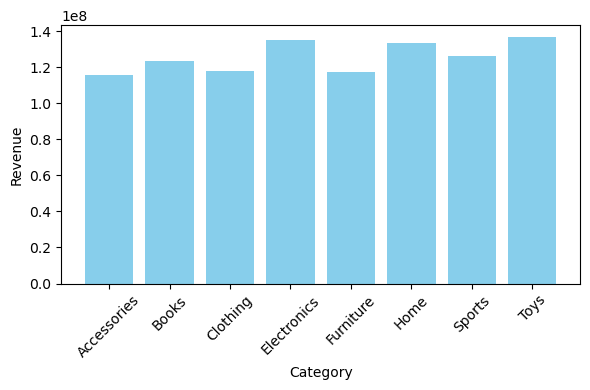

In [58]:
sales, products, stores, table_metadata =load_data()
print ("data load complete")
#    table_metadata = """Table: products; Columns: product_id	,product_name ,category	,brand	,price;
#                        Table: sales; Columns: sale_id	,product_id	,store_id	,quantity	,sale_date;
#                        Table: stores; Columns:store_id	,store_name	,city	,state	,region; """

Question = "show volume of sales, revenue by product category"

#llm_result = invoke_llm_openai(Question,table_metadata) #$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$
llm_result = invoke_llm_gai(Question,table_metadata) 
print(f"AI suggestion: ")
print(llm_result)

parsed = parse_sql_and_chart(llm_result)
#print(parsed)

valid, msg = query_validate(parsed["sql_query"])
print(f"Query Validation")
print(valid ,msg)
if valid:
    result = run_sql(parsed['sql_query'])   
    #print (result) 
    display_chart(parsed["chart"],result,parsed["x_coordinate"] , parsed["y_coordinate"])
else:
    print("modify the query for the LLM to answer query")
